### Imports

In [1]:
import pandas as pd
import os
import kagglehub
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
dataset_name = 'rmisra/news-headlines-dataset-for-sarcasm-detection'
file_name = 'Sarcasm_Headlines_Dataset_v2.json'

### Data Processing

In [2]:
path = kagglehub.dataset_download(dataset_name)
data_path = os.path.join(path, file_name)
df = pd.read_json(data_path, lines=True)

### Parsing

In [3]:
all_words = set()

for headline in df['headline']:
  words = headline.lower().split()
  for word in words:
    all_words.add(word)

all_words = list(all_words)
n_words = len(all_words)

In [4]:
headlines = []
word_dict = {}

for i, word in enumerate(all_words):
  word_dict[word] = i + 2 # for padding elements and unknown elements

for headline in df['headline']:
  words = headline.lower().split()
  indices = [word_dict.get(word, 1) for word in words]
  headline_tensor = torch.tensor(indices)
  headlines.append(headline_tensor)

### Encoding

In [5]:
padded_headlines = pad_sequence(headlines, batch_first=True, padding_value=0) # adds padding and unknown
labels = torch.tensor(df['is_sarcastic'].values, dtype=torch.float32)
dataset = TensorDataset(padded_headlines, labels)

train_size = int(len(dataset) * 0.85)
val_size = len(dataset) - train_size

train_ds, val_ds = random_split(dataset, [train_size, val_size])

train_dataloader = DataLoader(train_ds, batch_size=64, shuffle=True)
val_dataloader = DataLoader(val_ds, batch_size=64, shuffle=True)

### The Network

In [6]:
class SarcasmRNN(nn.Module):
  def __init__(self, n_words, embed_dim=128, hidden_dim=256):
    super().__init__()

    self.embedding = nn.Embedding(n_words, embed_dim, padding_idx=0)
    self.rnn = nn.RNN(embed_dim, hidden_dim, batch_first=True)
    self.fc = nn.Linear(hidden_dim, 1)
  
  def forward(self, x):
    embedded = self.embedding(x)
    # Counter-intuitive naming convention if you ask me
    # (out for vectors) and (hidden for output)?
    out, hidden = self.rnn(embedded)
    final = self.fc(hidden[-1])
    return final.squeeze(1)

### Setting parameters

In [7]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [8]:
# plus 2 for padding and unknown
model = SarcasmRNN(n_words+2).to(device)
epochs = 5
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

### Training and Validation

In [27]:
train_losses = {
    'avg': [],
    'abs': []
}

val_losses = {
    'avg': [],
    'abs': []
}

for e in range(epochs):
  avg_train_loss = 0
  train_correct = 0
  train_total = 0

  avg_val_loss = 0
  val_correct = 0
  val_total = 0

  model.train()
  for n, (X_train, y_train) in enumerate(train_dataloader):
    X_train = X_train.to(device)
    y_train = y_train.to(device)

    optimizer.zero_grad()

    y_pred = model(X_train)
    # Though y_pred is just logits I used BCEWithLogitsLoss so it takes care
    loss = criterion(y_pred, y_train)
    loss.backward()
    optimizer.step()
    # loss.item() gives avg loss for that batch
    avg_train_loss += loss.item() / len(train_dataloader)
    train_losses['abs'].append(loss.item())

    probability = F.sigmoid(y_pred)
    predictions = (probability > 0.5).float()

    train_correct += (predictions == y_train).sum().item()
    train_total += len(y_train)

  train_losses['avg'].append(avg_train_loss)
  print(f'Average Loss: {avg_train_loss}')
  print(f'Accuracy: {train_correct / train_total}')
  print('-------------------------')

  with torch.no_grad():
    model.eval()
    for n, (X_val, y_val) in enumerate(val_dataloader):
      X_val = X_val.to(device)
      y_val = y_val.to(device)

      y_pred = model(X_val)
      loss = criterion(y_pred, y_val)
      
      avg_val_loss += loss.item() / len(val_dataloader)

      val_losses['abs'].append(loss.item())

      probability = F.sigmoid(y_pred)
      predictions = (probability > 0.5).float()

      val_correct += (predictions == y_val).sum().item()
      val_total += len(y_val)
  
  val_losses['avg'].append(avg_val_loss)
  print(f'Average Validation Loss: {avg_val_loss}')
  print(f'Validation Accuracy: {val_correct / val_total}')
  print('-------------------------')


Average Loss: 0.6922283474541708
Accuracy: 0.5272958973937351
-------------------------
Average Validation Loss: 0.6903949073132345
Validation Accuracy: 0.5308641975308642
-------------------------
Average Loss: 0.6930403629625875
Accuracy: 0.5221162542135986
-------------------------
Average Validation Loss: 0.6916897060240018
Validation Accuracy: 0.5313300722105754
-------------------------
Average Loss: 0.6950664521828108
Accuracy: 0.5243361012908
-------------------------
Average Validation Loss: 0.6916442075196433
Validation Accuracy: 0.5317959468902865
-------------------------
Average Loss: 0.692675037959742
Accuracy: 0.5245005344076297
-------------------------
Average Validation Loss: 0.691641283385894
Validation Accuracy: 0.5317959468902865
-------------------------
Average Loss: 0.6927200303928748
Accuracy: 0.5263504069719641
-------------------------
Average Validation Loss: 0.6919865213772829
Validation Accuracy: 0.5303983228511531
-------------------------


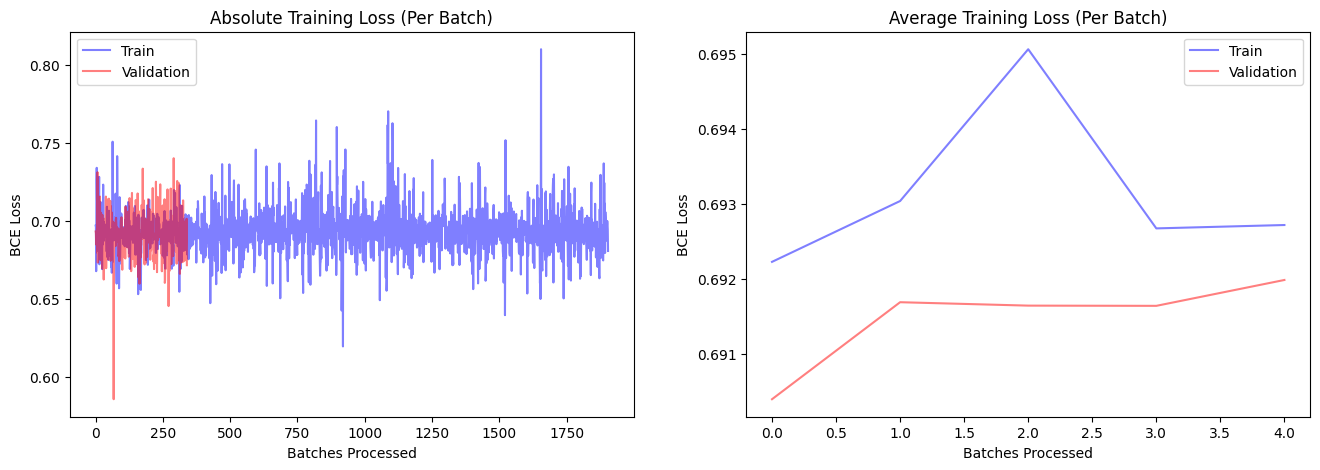

In [35]:
import matplotlib.pyplot as plt

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))

ax1.plot(train_losses['abs'], color='blue', alpha=0.5, label='Train')
ax1.plot(val_losses['abs'], color='red', alpha=0.5, label='Validation')
ax1.set_title("Absolute Training Loss (Per Batch)")
ax1.set_xlabel("Batches Processed")
ax1.set_ylabel("BCE Loss")
ax1.legend()

ax2.plot(train_losses['avg'], color='blue', alpha=0.5, label='Train')
ax2.plot(val_losses['avg'], color='red', alpha=0.5, label='Validation')
ax2.set_title("Average Training Loss (Per Batch)")
ax2.set_xlabel("Batches Processed")
ax2.set_ylabel("BCE Loss")
ax2.legend()

plt.show()